#   Quality Control - Cookie Production
**Statistical Analysis with Python**

---

**Objective:** Analyze the production data of a batch of cookies to assess weight consistency per ingredient, detect defective units and compare the weight of chocolate and vanilla cookies. 
**Tools:** `pandas`   `numpy`   `matplotlib`   `seaborn` scipy.stats`

**Dataset:** 12 sampled packages, with individual measurements of vanilla cookies, chocolate and packaging.


---
### 1.Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')


---
### 2.Data loading and cleaning
The data comes from a quality control laboratory. Each row represents a sampled package. Two vanilla cookies, two chocolate cookies and the weight of the packaging were measured.

>**note: Packages 9 and 10 contain the value 0 in Vainilla_2. These are not real zeroes - they are missing defective cookies. They will be replaced by 'NaN' to avoid statistical calculations being distorted.

In [2]:
galletas=pd.read_csv(r'D:/Users/HP/Desktop/Estudios/Analisis de datos/Portafolio/Datos Galletas-Pozuelo.csv',sep=';')

In [3]:
galletas

,Vanilla,Chocolate
0,7.50,7.64
1,7.54,7.62
2,7.73,7.62
3,7.56,7.61
4,7.46,7.87
5,7.80,7.76
6,7.90,7.71
7,7.61,7.64
8,7.57,7.85
9,7.79,7.80


## 3.Descriptive statistics
Calculation based on each type of cookie

In [4]:
estadistica=galletas[["Vanilla","Chocolate"]]

In [5]:
estadistica.describe()

,Vanilla,Chocolate
count,22.000000,24.00000
mean,7.676818,7.72000
std,0.283018,0.09065
min,7.010000,7.61000
25%,7.510000,7.63750
50%,7.750000,7.71500
75%,7.897500,7.79250
max,8.090000,7.87000


In [6]:
media=estadistica[['Vanilla','Chocolate']].mean()
mediana=estadistica[['Vanilla','Chocolate']].median()
moda=estadistica[['Vanilla','Chocolate']].mode()
varianza=estadistica [['Vanilla','Chocolate']].var()
coef_variacion = estadistica[['Vanilla','Chocolate']].std() / estadistica[['Vanilla','Chocolate']].mean()
curtosis = stats.kurtosis(estadistica[['Vanilla','Chocolate']].dropna())

In [7]:
media

Vanilla      7.676818
Chocolate    7.720000
dtype: float64

In [8]:
mediana


Vanilla      7.750
Chocolate    7.715
dtype: float64

In [9]:
moda

,Vanilla,Chocolate
0,7.46,7.62
1,NaN,7.64


In [10]:
varianza

Vanilla      0.080099
Chocolate    0.008217
dtype: float64

In [11]:
coef_variacion

Vanilla      0.036867
Chocolate    0.011742
dtype: float64

In [12]:
curtosis

array([ 0.05529992, -1.43253115])

## 4.Results
Analysis and vizualization of the pozuelo cookies of choolate and vanilla
### Histograms

<Axes: ylabel='Frequency'>

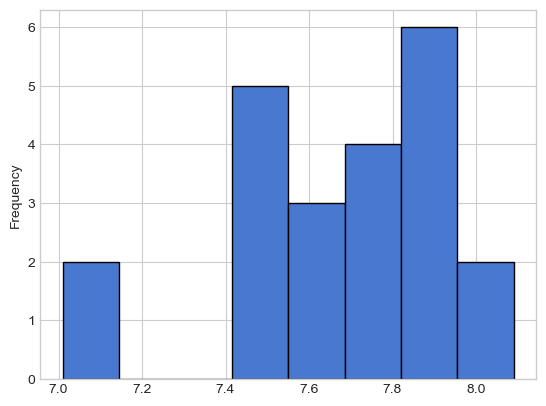

In [13]:
## Vanilla 

estadistica['Vanilla'].plot(kind='hist',bins=8,edgecolor='black')

<Axes: ylabel='Frequency'>

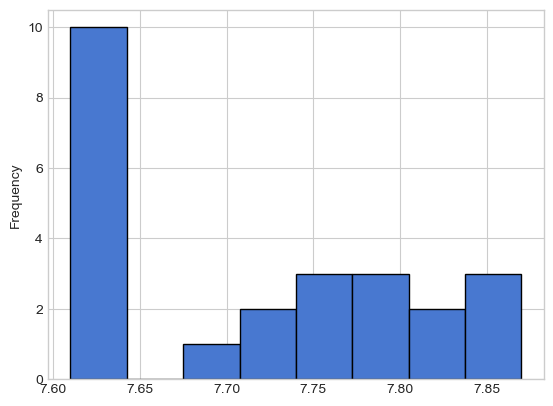

In [14]:
#Chocolate
estadistica['Chocolate'].plot(kind='hist',bins=8,edgecolor='black')

<Axes: ylabel='Frequency'>

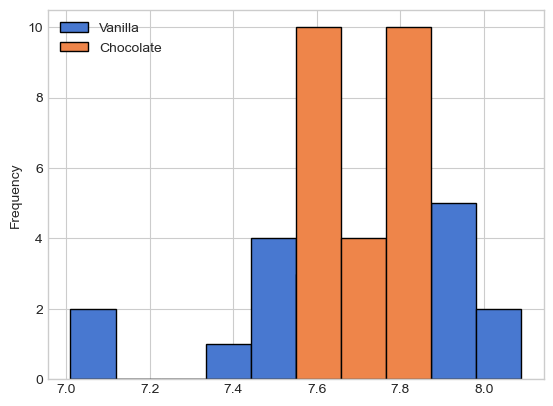

In [15]:
# Chocolate vs Vanilla
estadistica[['Vanilla', 'Chocolate']].plot(kind='hist',edgecolor='black')

Chocolate cookies have a higher weight and are more grouped than weights. Vanilla cookies have more variance, confirming the previous result of the coefficient of variance.

### Boxplot
Visual comparison of the median of vanilla and chocolate cookies

<Axes: >

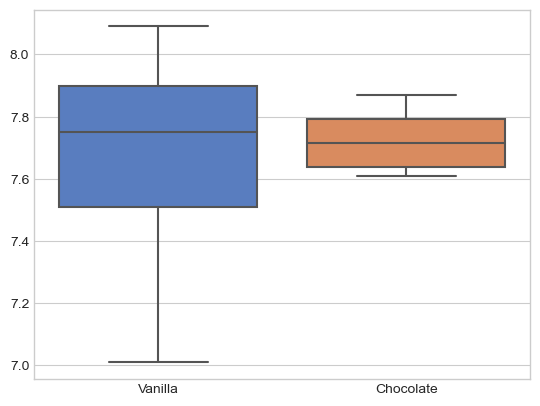

In [18]:

sns.boxplot(data=estadistica[['Vanilla', 'Chocolate']])

## Conclusion
Chocolate cookies have a higher average weight (7.72 grams) than vanilla cookies (7.67 grams). Moreover, the box plots show that vanilla cookies have greater weight variance